In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

2026-06-01 17:50:49.361993: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-01 17:50:49.362465: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-01 17:50:49.427093: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-01 17:50:50.956321: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

# Data Extraction & Feature Engineering

In [2]:
# Placeholder ticker,add a list to extract a portfolio
ticker = "AAPL"

df = yf.download(ticker, start="2015-01-01", end="2026-01-01")
df = df[["Close", "Volume"]].copy()

# technical Features
# simple Moving Average
df["SMA_20"]  = df["Close"].rolling(window=20).mean()
df["SMA_50"]  = df["Close"].rolling(window=50).mean()
df["SMA_200"] = df["Close"].rolling(window=200).mean()

# rolling volatility 
df["Log_Return"]    = np.log(df["Close"] / df["Close"].shift(1))
df["Volatility_20"] = df["Log_Return"].rolling(window=20).std()

# daily returns
df["returns"] = df["Close"].pct_change()

#target returns
df["future_return"] = df["Close"].pct_change().shift(-1)


# SMA Crossover Signal: 1 when SMA_20 > SMA_50 (bullish), -1 otherwise
df["SMA_Signal"] = np.where(df["SMA_20"] > df["SMA_50"], 1, -1)

# Drop NaN rows
df.dropna(inplace=True)

print(f"Feature columns: {list(df.columns)}")
print(f"Data shape after feature engineering: {df.shape}")
df.head()

[*********************100%***********************]  1 of 1 completed

Feature columns: [('Close', 'AAPL'), ('Volume', 'AAPL'), ('SMA_20', ''), ('SMA_50', ''), ('SMA_200', ''), ('Log_Return', ''), ('Volatility_20', ''), ('returns', ''), ('future_return', ''), ('SMA_Signal', '')]
Data shape after feature engineering: (2566, 10)


Price,Close,Volume,SMA_20,SMA_50,SMA_200,Log_Return,Volatility_20,returns,future_return,SMA_Signal
Ticker,AAPL,AAPL,,,,,,,,
Date,,,,,,,,,,
2015-10-16,24.883131,156930400,25.046606,25.176153,27.035150,-0.007358,0.013340,-0.007331,0.006214,-1
2015-10-19,25.037750,119036800,25.007613,25.159167,27.039376,0.006195,0.012893,0.006214,0.018258,-1
2015-10-20,25.494892,195871200,25.011759,25.132500,27.049295,0.018093,0.013142,0.018258,-0.000088,-1
2015-10-21,25.492661,167180800,25.005484,25.133710,27.059192,-0.000088,0.013009,-0.000088,0.015295,-1
2015-10-22,25.882578,166616400,25.011086,25.134875,27.069390,0.015179,0.013399,0.015295,0.030996,-1


# Visualize Price Data

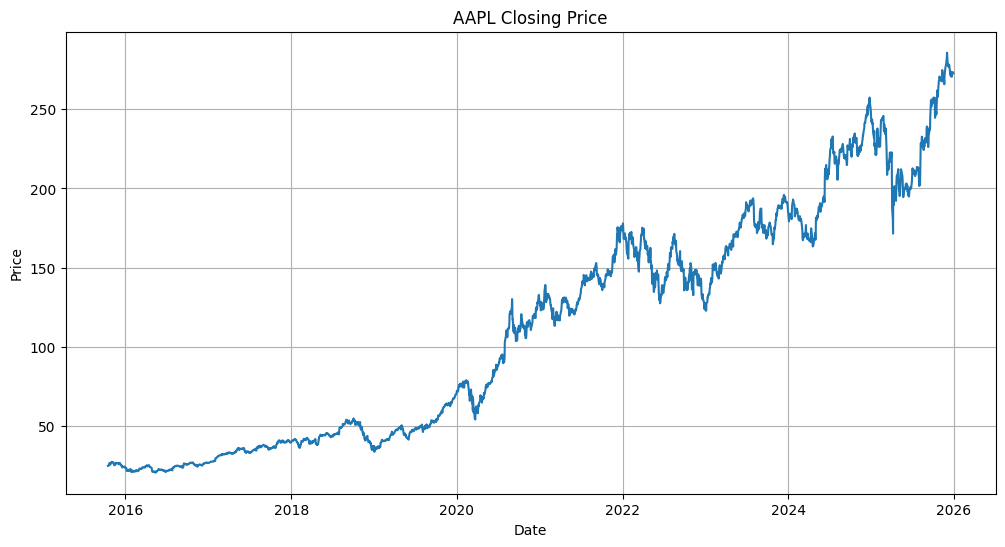

In [3]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"])
plt.title(f"{ticker} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# Scale The Data, Create Sequential Windows & Train-Test Split

In [4]:
# feature & target columns 
feature_cols = ["Close", "SMA_20", "SMA_50", "Volatility_20", "returns"]
target_col   = "future_return"   # LSTM predicts next-day return, not price

#temporal split before scaler 
split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx]
df_test  = df.iloc[split_idx:]

# Fit scalers on train data only; only transform test
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler  = MinMaxScaler(feature_range=(0, 1))

train_features_scaled = feature_scaler.fit_transform(df_train[feature_cols])
test_features_scaled  = feature_scaler.transform(df_test[feature_cols])    # transform only

train_target_scaled = target_scaler.fit_transform(df_train[[target_col]])
test_target_scaled  = target_scaler.transform(df_test[[target_col]])        # transform only

# Build rolling sequences
sequence_length = 60
n_features = len(feature_cols)

def build_sequences(features, targets, seq_len):
    X, y = [], []
    for i in range(seq_len, len(features)):
        X.append(features[i - seq_len:i, :])  # (seq_len, n_features)
        y.append(targets[i, 0])               # scalar — next-day return
    return np.array(X), np.array(y)

X_train, y_train = build_sequences(train_features_scaled, train_target_scaled, sequence_length)
X_test,  y_test  = build_sequences(test_features_scaled,  test_target_scaled,  sequence_length)

print("X_train shape:", X_train.shape, "  y_train shape:", y_train.shape)
print("X_test  shape:", X_test.shape,  "  y_test  shape:", y_test.shape)

X_train shape: (1992, 60, 5)   y_train shape: (1992,)
X_test  shape: (454, 60, 5)   y_test  shape: (454,)


# Build & Train The LSTM Model

In [5]:
model = Sequential()

model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(units=64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")

model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

2026-06-01 17:50:52.712476: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,009 (199.25 KB)

 Trainable params: 51,009 (199.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 0.0166 - val_loss: 0.0056
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0083 - val_loss: 0.0093
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0077 - val_loss: 0.0059
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0075 - val_loss: 0.0063
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0076 - val_loss: 0.0068
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0073 - val_loss: 0.0054
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0071 - val_loss: 0.0058
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0072 - val_loss: 0.0054
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0067 - val_loss: 0.0056
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0072 - val_loss: 0.0061
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0072 - val_loss: 0.0055
Epoch 12/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0

In [6]:
# prediction on test data
pred_return_scaled = model.predict(X_test)

# inverse-transform to unscale the scaled data
pred_returns   = target_scaler.inverse_transform(pred_return_scaled).flatten()
actual_returns = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(actual_returns, pred_returns)
rmse = np.sqrt(mean_squared_error(actual_returns, pred_returns))
direction_acc = np.mean(np.sign(pred_returns) == np.sign(actual_returns))

print(f"MAE  (next-day return) : {mae:.6f}")
print(f"RMSE (next-day return) : {rmse:.6f}")
print(f"Directional Accuracy   : {direction_acc:.2%}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
MAE  (next-day return) : 0.011774
RMSE (next-day return) : 0.018183
Directional Accuracy   : 56.61%


# Visuals

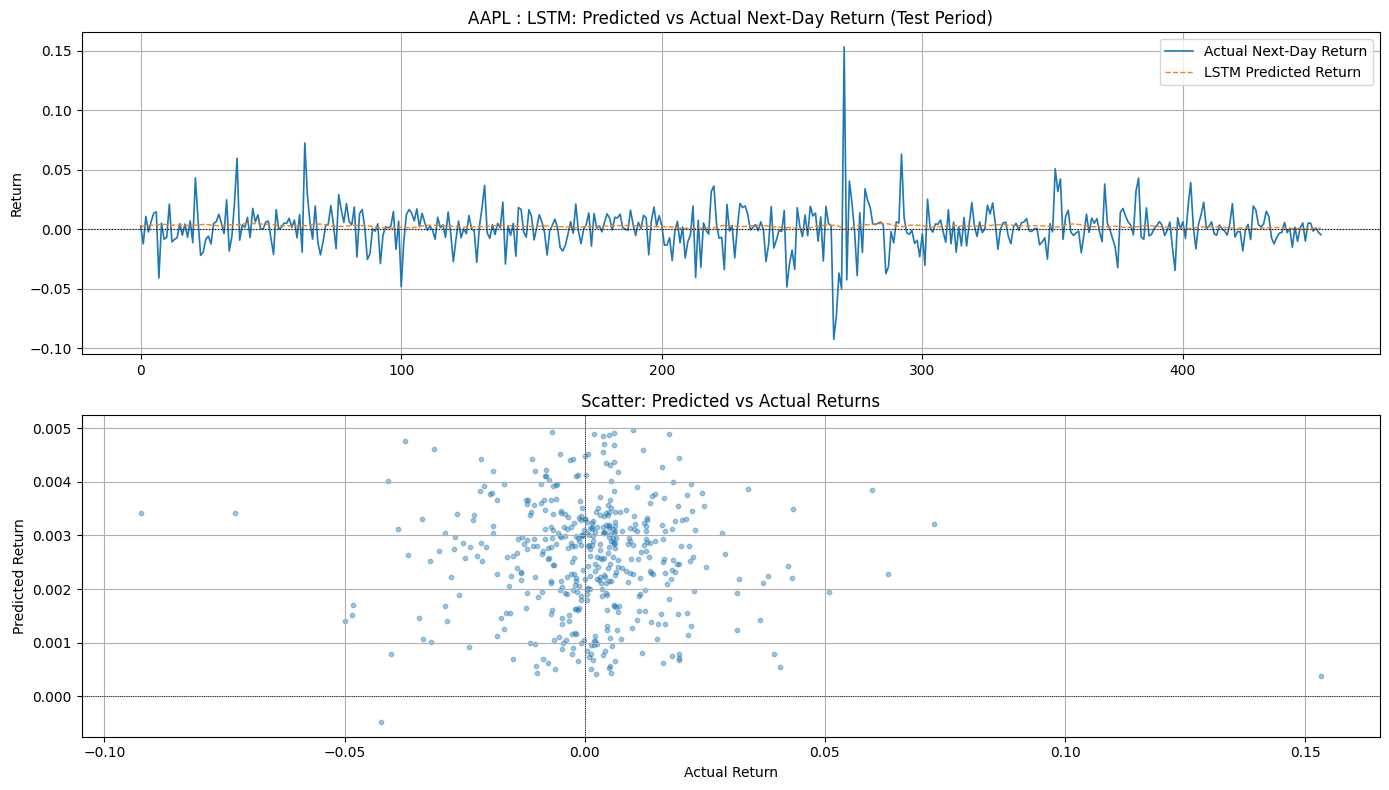

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(actual_returns, label="Actual Next-Day Return", linewidth=1.2)
axes[0].plot(pred_returns,   label="LSTM Predicted Return", linestyle="--", linewidth=1)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[0].set_title(f"{ticker} : LSTM: Predicted vs Actual Next-Day Return (Test Period)")
axes[0].set_ylabel("Return")
axes[0].legend(); axes[0].grid(True)

axes[1].scatter(actual_returns, pred_returns, alpha=0.4, s=10)
axes[1].axhline(0, color="black", linewidth=0.6, linestyle=":")
axes[1].axvline(0, color="black", linewidth=0.6, linestyle=":")
axes[1].set_xlabel("Actual Return")
axes[1].set_ylabel("Predicted Return")
axes[1].set_title("Scatter: Predicted vs Actual Returns")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Trading Strategy

In [8]:
#align predictions with dates
# Test sequences start at row `sequence_length` inside df_test
test_dates = df_test.index[sequence_length:]

strategy_df = pd.DataFrame(index=test_dates)
strategy_df["Close"]         = df_test["Close"].values[sequence_length:]
strategy_df["actual_return"] = actual_returns
strategy_df["pred_return"]   = pred_returns

# signal generation from the ML model
# long (+1) when LSTM predicts positive next-day return, Flat (0) otherwise
# extend to -1 for Short if short-selling is allowed
strategy_df["signal"] = np.where(strategy_df["pred_return"] > 0, 1, 0)

# shift by 1, prediction at close of day t -> position entered at open of day t+1
# avoids look-ahead bias in the backtest
strategy_df["position"] = strategy_df["signal"].shift(1).fillna(0)

# Returns & cumulative retruns
strategy_df["market_return"]   = strategy_df["Close"].pct_change().fillna(0)
strategy_df["strategy_return"] = strategy_df["position"] * strategy_df["market_return"]
strategy_df["cumulative_market"]   = (1 + strategy_df["market_return"]).cumprod()
strategy_df["cumulative_strategy"] = (1 + strategy_df["strategy_return"]).cumprod()

# Performance metrics
total_return_strategy = strategy_df["cumulative_strategy"].iloc[-1] - 1
total_return_market   = strategy_df["cumulative_market"].iloc[-1] - 1

sharpe = (
    strategy_df["strategy_return"].mean() /
    (strategy_df["strategy_return"].std() + 1e-9)
) * np.sqrt(252)

cum          = strategy_df["cumulative_strategy"]
rolling_max  = cum.cummax()
drawdown     = (cum - rolling_max) / rolling_max
max_drawdown = drawdown.min()

win_rate = (strategy_df["strategy_return"] > 0).mean()

print(f"Strategy Total Return  : {total_return_strategy:.2%}")
print(f"Market Total Return    : {total_return_market:.2%}")
print(f"Sharpe Ratio           : {sharpe:.4f}")
print(f"Max Drawdown           : {max_drawdown:.2%}")
print(f"Win Rate               : {win_rate:.2%}")

Strategy Total Return  : 66.42%
Market Total Return    : 59.37%
Sharpe Ratio           : 1.1335
Max Drawdown           : -33.36%
Win Rate               : 56.39%


# Visualize Strategy performance

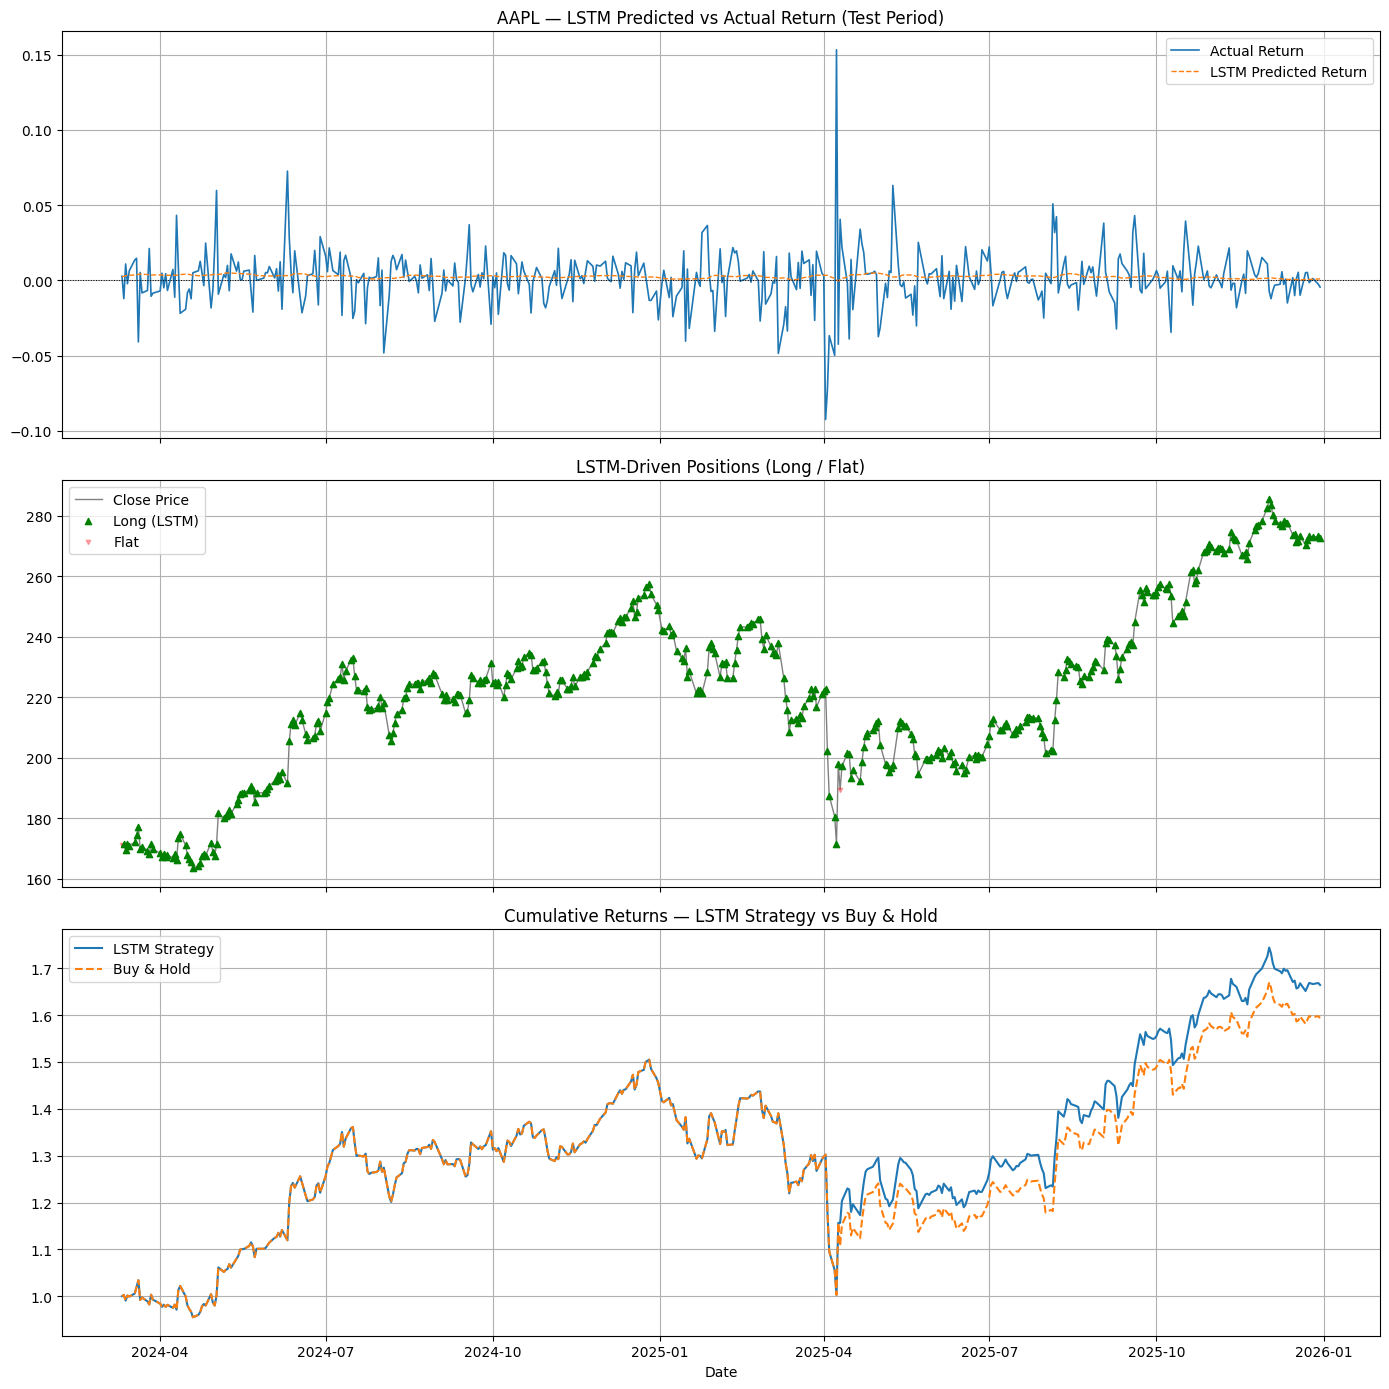

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

# LSTM predicted vs actual return
axes[0].plot(strategy_df.index, strategy_df["actual_return"],
             label="Actual Return", linewidth=1.2)
axes[0].plot(strategy_df.index, strategy_df["pred_return"],
             label="LSTM Predicted Return", linestyle="--", linewidth=1)
axes[0].axhline(0, color="black", linewidth=0.7, linestyle=":")
axes[0].set_title(f"{ticker} — LSTM Predicted vs Actual Return (Test Period)")
axes[0].legend(); axes[0].grid(True)

# LSTM-driven positions overlaid on Closing price
axes[1].plot(strategy_df.index, strategy_df["Close"],
             label="Close Price", linewidth=1, color="grey")
long_pts = strategy_df[strategy_df["position"] == 1]
flat_pts = strategy_df[strategy_df["position"] == 0]
axes[1].scatter(long_pts.index, long_pts["Close"],
                marker="^", color="green", s=20, label="Long (LSTM)", zorder=5)
axes[1].scatter(flat_pts.index, flat_pts["Close"],
                marker="v", color="red", s=10, alpha=0.3, label="Flat", zorder=4)
axes[1].set_title("LSTM-Driven Positions (Long / Flat)")
axes[1].legend(); axes[1].grid(True)

# Cumulative returns
axes[2].plot(strategy_df.index, strategy_df["cumulative_strategy"],
             label="LSTM Strategy", linewidth=1.5)
axes[2].plot(strategy_df.index, strategy_df["cumulative_market"],
             label="Buy & Hold", linewidth=1.5, linestyle="--")
axes[2].set_title("Cumulative Returns — LSTM Strategy vs Buy & Hold")
axes[2].set_xlabel("Date")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

# Export Data

In [ ]:
results = pd.DataFrame({
    "Actual": y_test_actual.flatten(),
    "Predicted": predictions.flatten()
})

results.to_csv("lstm_portfolio_forecasts.csv", index=False)

results.head()